# Mini-Projeto: Modelagem e Solução de Problemas com Aprendizado por Reforço

**Alunos:** [Insira o nome dos integrantes do grupo aqui]

Neste notebook, vocês irão desenvolver o projeto prático da disciplina. O objetivo é aplicar os algoritmos tabulares clássicos em um ambiente de espaço contínuo (`MountainCar-v0`), utilizando técnicas de discretização, conforme o enunciado.

Deixe, neste colab, somente o código necessário para treinar os agentes com a parametrização mais vantajosa e gerar os gráficos, além do relatório em texto, na **análise dos resultados** e no **diário de bordo**. O restante da experimentação pode ser feito em outros colabs e ambientes. O diário de bordo deve comentar essa jornada e pode referenciar esses outros artefatos.

## Tarefa A: Modelagem do Espaço de Estados (Discretização)

Implementem abaixo **duas formas ou resoluções de discretização diferentes**

In [1]:
# ==============================================================================
# TAREFA A: FUNÇÕES DE DISCRETIZAÇÃO
# ==============================================================================

import gymnasium as gym
from modules.discretization import StateDiscretizer, get_coarse_discretizer, get_fine_discretizer

# Criando ambiente base para obtenção dos limites do espaço de observação
env = gym.make("MountainCar-v0")

# Discretização 1: Grossa (Coarse - 10x10 bins = 100 estados discretos)
discretizer_coarse = get_coarse_discretizer(env)

# Discretização 2: Fina (Fine - 40x40 bins = 1600 estados discretos)
discretizer_fine = get_fine_discretizer(env)

## Tarefa B: Implementação dos Agentes Tabulares
Implementem os algoritmos solicitados.

In [2]:
# ==============================================================================
# TAREFA B: AGENTES
# ==============================================================================

from modules.agents import BaseAgent, QLearningAgent, SarsaLambdaAgent, DynaQAgent

# Os agentes tabulares (Baseline / Q-Learning, SARSA(λ) e Dyna-Q) estão implementados
# no módulo `modules.agents` importado acima.

## Tarefa C: Avaliação Experimental e Reprodutibilidade
Treine cada algoritmo pelo menos 10 vezes com sementes diferentes (seeds) para lidar com a alta variância do Aprendizado por Reforço.

In [3]:
# ==============================================================================
# TAREFA C: Execução dos experimentos para ambas as representações
# ==============================================================================

import pandas as pd
from modules.experiments import run_experiment

# Configuração de 10 sementes fixas para reprodutibilidade
seeds = [10, 22, 33, 44, 55, 66, 77, 88, 99, 100]
episodes = 500

# ------------------------------------------------------------------------------
# 1. Experimentos na Discretização Grossa (10x10 bins)
# ------------------------------------------------------------------------------
print("--- Rodando experimentos na Discretização Grossa (10x10) ---")
df_q_coarse = run_experiment(QLearningAgent, discretizer_coarse, episodes=episodes, seeds=seeds, representation_name="Grossa (10x10)")
df_sarsa_coarse = run_experiment(SarsaLambdaAgent, discretizer_coarse, episodes=episodes, seeds=seeds, lambd=0.9, representation_name="Grossa (10x10)")
df_dyna_coarse = run_experiment(DynaQAgent, discretizer_coarse, episodes=episodes, seeds=seeds, n_planning_steps=10, representation_name="Grossa (10x10)")

# ------------------------------------------------------------------------------
# 2. Experimentos na Discretização Fina (40x40 bins)
# ------------------------------------------------------------------------------
print("--- Rodando experimentos na Discretização Fina (40x40) ---")
df_q_fine = run_experiment(QLearningAgent, discretizer_fine, episodes=episodes, seeds=seeds, representation_name="Fina (40x40)")
df_sarsa_fine = run_experiment(SarsaLambdaAgent, discretizer_fine, episodes=episodes, seeds=seeds, lambd=0.9, representation_name="Fina (40x40)")
df_dyna_fine = run_experiment(DynaQAgent, discretizer_fine, episodes=episodes, seeds=seeds, n_planning_steps=10, representation_name="Fina (40x40)")

# Consolidação de todos os experimentos em um único DataFrame
df_all = pd.concat([df_q_coarse, df_sarsa_coarse, df_dyna_coarse, df_q_fine, df_sarsa_fine, df_dyna_fine], ignore_index=True)

--- Rodando experimentos na Discretização Grossa (10x10) ---


Treinando DynaQAgent [Grossa (10x10)]: 100%|██████████| 10/10 [02:34<00:00, 15.41s/it]


--- Rodando experimentos na Discretização Fina (40x40) ---


Treinando DynaQAgent [Fina (40x40)]: 100%|██████████| 10/10 [28:38<00:00, 171.82s/it]


## 4.1 Gráficos de Curva de Aprendizado

Com os dados coletados, gerem os dois conjuntos de gráficos exigidos. Utilizem o `seaborn.lineplot`, pois ele calcula e desenha o Intervalo de Confiança de 95% automaticamente ao receber dados de múltiplas repetições (seeds).

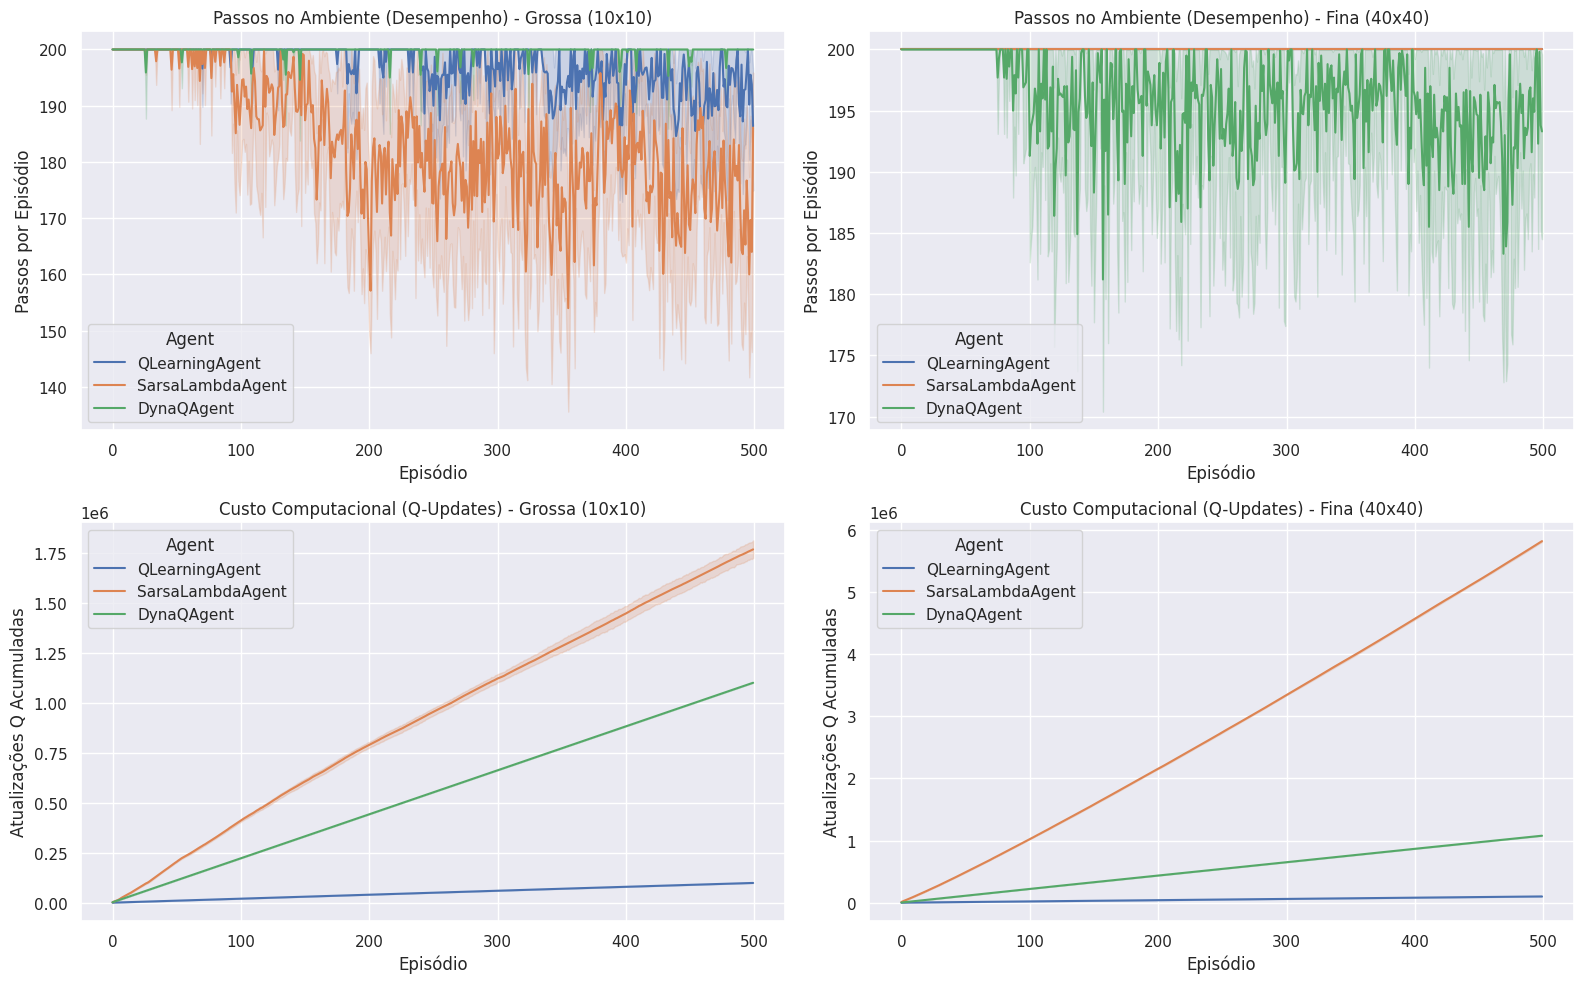

--- Tabela Estatística Resumo (Média e Desvio Padrão nos últimos episódios e Total de Q-Updates) ---


,Representation,Agent,Mean_Final_Steps,Std_Final_Steps,Mean_Total_Q_Updates,Std_Total_Q_Updates
0,Fina (40x40),DynaQAgent,193.437255,13.249568,1077364.2,4916.820355
1,Fina (40x40),QLearningAgent,200.000000,0.000000,100000.0,0.000000
2,Fina (40x40),SarsaLambdaAgent,200.000000,0.000000,5817805.6,19232.103532
3,Grossa (10x10),DynaQAgent,199.805882,2.281635,1099107.9,953.001160
4,Grossa (10x10),QLearningAgent,192.900000,15.174033,98653.0,496.235831
5,Grossa (10x10),SarsaLambdaAgent,175.178431,25.942765,1765603.9,73008.604014


In [4]:
# ==============================================================================
# GRÁFICOS E DADOS DETALHADOS PARA TOMADA DE DECISÃO
# ==============================================================================

from modules.experiments import plot_learning_curves, summarize_experiments
from IPython.display import display

# 1. Geração dos gráficos comparativos com Intervalo de Confiança de 95% para ambas as representações
# Exibe um painel contendo:
# - Eixo x: Contagem de episódios
# - Eixo y (Desempenho): Número de passos até o sucesso (média + sombreamento IC 95%)
# - Eixo y (Custo): Número de atualizações de valor-Q acumuladas (média + sombreamento IC 95%)
plot_learning_curves(df_all)

# 2. Apresentação da Tabela Resumo com dados estatísticos agregados para tomada de decisão
print("--- Tabela Estatística Resumo (Média e Desvio Padrão nos últimos episódios e Total de Q-Updates) ---")
summary_table = summarize_experiments(df_all)
display(summary_table)

## 4.2 Análise de Resultados e Aliasing de Estados

*(Respondam de forma dissertativa, embasando-se nos gráficos gerados acima)*

**a) Qual o melhor algoritmo em termos de eficiência amostral?**
> Escreva sua resposta aqui...

**b) Qual o melhor algoritmo em termos de eficiência computacional?**
> Escreva sua resposta aqui...

**c) Como a modelagem de estados afetou especificamente o modelo construído pelo Dyna-Q em comparação com o SARSA(λ)? Pense na relação entre as transições reais do ambiente vs nos estados discretizados.**
> Escreva sua resposta detalhada sobre a modelagem de estados aqui...

In [14]:
!uv add pygame
%load_ext autoreload
%autoreload 2

Resolved 91 packages in 351ms                                        
Prepared 1 package in 3.88s                                                  pygame               ------------------------------ 13.16 MiB/13.33 MiB         
Installed 1 package in 11ms                                 
 + pygame==2.6.1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# ==============================================================================
# GRAVAÇÃO E EXIBIÇÃO DE VÍDEO DOS AGENTES TREINADOS
# ==============================================================================
# Salve um ou mais episódios dos seus agentes que valem a pena serem vistos

import os
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import Video, display
from modules.agents import SarsaLambdaAgent, DynaQAgent

video_dir = "./videos"
os.makedirs(video_dir, exist_ok=True)

def record_and_display_agent(agent_cls, discretizer, rep_name, seed=42, **agent_kwargs):
    env_raw = gym.make("MountainCar-v0", render_mode="rgb_array")
    prefix = f"{agent_cls.__name__}_{rep_name.replace(' ', '_').replace('(', '').replace(')', '')}"
    env_rec = RecordVideo(env_raw, video_folder=video_dir, name_prefix=prefix, episode_trigger=lambda ep: True)
    
    agent = agent_cls(env_rec.action_space, **agent_kwargs)
    state, _ = env_rec.reset(seed=seed)
    state_d = discretizer.discretize(state)
    
    done = False
    truncated = False
    steps = 0
    
    if hasattr(agent, 'reset_traces'):
        agent.reset_traces()
    action = agent.act(state_d)
    
    while not (done or truncated):
        next_state, reward, done, truncated, _ = env_rec.step(action)
        next_state_d = discretizer.discretize(next_state)
        next_action = agent.act(next_state_d)
        
        if hasattr(agent, 'reset_traces'):
            agent.learn(state_d, action, reward, next_state_d, next_action, done)
        else:
            agent.learn(state_d, action, reward, next_state_d, done)
            
        state_d = next_state_d
        action = next_action
        steps += 1
        
    env_rec.close()
    print(f"Vídeo gerado para {agent_cls.__name__} [{rep_name}] ({steps} passos)")

# Demonstração dos agentes nas diferentes representações
record_and_display_agent(SarsaLambdaAgent, discretizer_coarse, "Grossa (10x10)", lambd=0.9)
record_and_display_agent(DynaQAgent, discretizer_coarse, "Grossa (10x10)", n_planning_steps=10)

# Exibição dos vídeos salvos no notebook
for video_file in sorted(os.listdir(video_dir)):
    if video_file.endswith(".mp4"):
        video_path = os.path.join(video_dir, video_file)
        print(f"Exibindo: {video_file}")
        display(Video(video_path, embed=True, width=600))

Vídeo gerado para SarsaLambdaAgent [Grossa (10x10)] (200 passos)
Vídeo gerado para DynaQAgent [Grossa (10x10)] (200 passos)
Exibindo: DynaQAgent_Grossa_10x10-episode-0.mp4


Exibindo: SarsaLambdaAgent_Grossa_10x10-episode-0.mp4


## 4.3 Diário de Bordo e Registro de Falhas


**a) O que notadamente falhou nas escolhas de hiperparâmetros (alpha, decaimento de epsilon, λ, N)? Por que falharam?**
> Escreva sua resposta aqui...

**b) Houve alguma dificuldade ou erros na implementação de alguma etapa do projeto? Como foi resolvido?**
> Escreva sua resposta aqui...

**c) O que mais vale a pena relatar que não foi coberto nas demais perguntas?**
> Escreva sua resposta aqui...